# Rebalancing Engine — Monthly Trade Sheet

**What this does**: Takes your actual holdings today and produces a line-by-line buy/sell list with exact share counts and cost estimates.

**Run this once a month**, at month-end, *before* placing any orders.

---
**Workflow**:
1. Edit **Cell 2** — enter your actual holdings and cash
2. Edit **Cell 3** — set your broker and cost settings
3. Run all cells
4. Follow the trade sheet produced at the end


In [63]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

from src.data import refresh_data, compute_returns
from src.signals import run_signal_pipeline
from src.rebalancer import (
    fetch_live_prices, compute_current_state,
    get_target_weights, build_trade_sheet, validate_cash,
    print_trade_sheet, compute_target_shares
)

plt.rcParams.update({'figure.dpi':130,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})
print('Ready.')

Ready.


## STEP 1 — Enter Your Current Holdings

Edit the cell below. Set `shares = 0` for ETFs you do not currently hold.
If this is your **first time investing**, set everything to 0 and set `CASH` to your starting capital.

> **Currency note**: these ETFs trade in **USD** on US exchanges.  
> If your broker (e.g. IBKR) converts GBP→USD automatically, enter your GBP cash amount converted at today's FX rate, or let IBKR handle the conversion.


In [64]:
# ─────────────────────────────────────────────────────
# EDIT THIS CELL before running the notebook
# ─────────────────────────────────────────────────────

HOLDINGS = {
    # ETF    : shares you currently own
    'SPY'  : 0,
    'QQQ'  : 0,
    'IWM'  : 0,
    'VGK'  : 0,
    'EEM'  : 0,
    'TLT'  : 0,
    'IEF'  : 0,
    'SHY'  : 0,
    'BIL'  : 0,
    'GLD'  : 0,
    'SLV'  : 0,
    'DBC'  : 0,
    'USO'  : 0,
    'UNG'  : 0,
    'VNQ'  : 0,
}

CASH = 10_00.00   # uninvested cash in your account (USD or GBP equivalent)

print(f'Total holdings entered: {sum(v for v in HOLDINGS.values() if v > 0)} positions')
print(f'Cash available: ${CASH:,.2f}')

Total holdings entered: 0 positions
Cash available: $1,000.00


## STEP 2 — Set Your Broker Settings

| Broker | Fractional? | Commission | Notes |
|--------|-------------|------------|-------|
| IBKR Pro (Tiered) | Yes | ~$0.35-$1/trade flat | Best for small accounts |
| IBKR Lite | Yes | $0 | US residents only |
| Fidelity UK | No | £0 on ETFs | Whole shares only |
| Freetrade | Yes (fractional) | £0 basic | Fractional ETF units |
| Hargreaves Lansdown | No | £11.95/trade | Very expensive — check below |


In [65]:
# ─────────────────────────────────────────────────────
# EDIT THIS CELL to match your broker
# ─────────────────────────────────────────────────────

FRACTIONAL_SHARES    = True   # True: IBKR/Freetrade. False: HL/Fidelity UK
COMMISSION_PER_TRADE = 0.0     # Flat fee per order in $ (IBKR: ~0.35-1.0)
COMMISSION_PCT       = 0.0     # % of trade value (HL: charge % on large trades)
MIN_TRADE_PCT        = 0.005   # Skip trades < 0.5% of portfolio (reduces churn)
N_TOP                = 5       # Must match your backtest setting (default: 5)
CURRENCY             = '$'     # '$' or 'GBP sign' for display

print('Broker settings saved.')
print(f'  Fractional shares    : {FRACTIONAL_SHARES}')
print(f'  Commission per trade : {CURRENCY}{COMMISSION_PER_TRADE:.2f}')
print(f'  Commission pct       : {COMMISSION_PCT:.2f}%')
print(f'  Min trade threshold  : {MIN_TRADE_PCT*100:.1f}% of portfolio')
print(f'  Top-N selection      : {N_TOP}')

Broker settings saved.
  Fractional shares    : True
  Commission per trade : $0.00
  Commission pct       : 0.00%
  Min trade threshold  : 0.5% of portfolio
  Top-N selection      : 5


## STEP 3 — Load Data and Run (no edits needed below this line)

In [66]:
# Download only the new trading days since last run (~5-10 seconds)
prices  = refresh_data(proc_dir='../data/processed', config_path='../config/universe.yaml')
returns = compute_returns(prices)

# Recompute signals on fresh prices and save to disk
signals = run_signal_pipeline(prices, returns, proc_dir='../data/processed')

print(f'\nPrices : {prices.shape[0]} days × {prices.shape[1]} ETFs')
print(f'Latest : {prices.index[-1].date()}')

Data already up to date (2026-06-30).
Computing momentum signals ...
Saved 8 signal files -> ../data/processed/

Signal matrix: 258 month-ends x 15 tickers
Date range   : 2005-01-31 -> 2026-06-30

Latest month-end snapshot: 2026-06-30
Ticker      Score     3M%     6M%     12M%    Vol%  Eligible
------------------------------------------------------------
USO        0.3682  -17.3%   56.8%    46.5%   55.5%       YES
EEM        0.3423   24.6%   24.5%    43.9%   33.1%       YES
IWM        0.3078   24.9%   19.3%    40.0%   19.5%       YES
QQQ        0.2832   30.9%   17.3%    33.9%   23.4%       YES
SLV        0.2167  -15.6%  -24.6%    64.3%   52.2%        NO
SPY        0.1716   17.9%    8.2%    22.2%   14.0%       YES
DBC        0.1690   -8.7%   17.7%    26.7%   21.3%       YES
VGK        0.1335   12.0%    7.0%    17.7%   19.5%       YES
VNQ        0.1252   11.8%   11.1%    13.7%   15.4%       YES
GLD        0.0588  -10.8%  -11.2%    22.8%   23.9%        NO
TLT        0.0274    1.5%    1.1%

## HRP Target Weights (This Month)

In [67]:
target_weights = get_target_weights(signals, prices, n_top=N_TOP)
latest_date    = prices.resample('ME').last().index[-1]

print(f'Signal date: {latest_date.strftime("%B %Y")}')
print(f'Selected ETFs ({len(target_weights)}):')
for tkr, wt in target_weights.items():
    print(f'  {tkr:<6}: {wt*100:.1f}%')

Signal date: June 2026
Selected ETFs (5):
  EEM   : 48.4%
  SPY   : 18.4%
  IWM   : 14.9%
  QQQ   : 10.9%
  USO   : 7.3%


## Live Prices

Fetched via Yahoo Finance. These are the prices used to compute share counts.
If the market is closed, you'll get the last closing price.


In [68]:
all_tickers = sorted(set(list(HOLDINGS.keys())) | set(list(target_weights.index)))
live_prices = fetch_live_prices(all_tickers, fallback_prices=prices)

price_df = pd.DataFrame([
    {'ETF': tkr, 'Price': live_prices.get(tkr, float('nan'))}
    for tkr in all_tickers
])
print(price_df.to_string(index=False))

ETF      Price
BIL  91.639999
DBC  26.660000
EEM  68.410004
GLD 368.380005
IEF  94.570000
IWM 300.450012
QQQ 736.400024
SHY  82.110001
SLV  53.470001
SPY 746.770020
TLT  86.419998
UNG  11.720000
USO 106.440002
VGK  88.540001
VNQ  96.430000


## Current Portfolio State

In [57]:
current = compute_current_state(HOLDINGS, live_prices, CASH)

print(f'Portfolio value : {CURRENCY}{current["total"]:>10,.2f}')
print(f'Invested        : {CURRENCY}{current["invested"]:>10,.2f}')
print(f'Cash            : {CURRENCY}{current["cash"]:>10,.2f}')
print()
if current['positions']:
    print(f'  {"ETF":<6}  {"Shares":>8}  {"Price":>8}  {"Value":>12}  {"Weight":>8}')
    print(f'  {"-"*6}  {"-"*8}  {"-"*8}  {"-"*12}  {"-"*8}')
    for tkr, pos in current['positions'].items():
        if pos['shares'] > 0:
            print(f'  {tkr:<6}  {pos["shares"]:>8.2f}  '
                  f'{CURRENCY}{pos["price"]:>7.2f}  '
                  f'{CURRENCY}{pos["value"]:>11,.2f}  '
                  f'{pos["weight"]*100:>7.1f}%')
else:
    print('  (no current positions — starting from scratch)')

Portfolio value : $  1,000.00
Invested        : $      0.00
Cash            : $  1,000.00

  ETF       Shares     Price         Value    Weight
  ------  --------  --------  ------------  --------


## Trade Sheet

Execution order: **SELL first** (frees up cash), then **BUY**.  
Trades below the minimum threshold are shown as HOLD to avoid unnecessary churn.

In [58]:
from src.rebalancer import compute_target_shares

target = compute_target_shares(
    target_weights, current['total'], live_prices,
    fractional_shares=FRACTIONAL_SHARES
)

trade_df = build_trade_sheet(
    current, target, live_prices,
    spread_bps=2.0,
    commission_per_trade=COMMISSION_PER_TRADE,
    commission_pct=COMMISSION_PCT,
    min_trade_pct=MIN_TRADE_PCT,
)

cash_check = validate_cash(trade_df, current['cash'])
print_trade_sheet(trade_df, current, cash_check, latest_date, CURRENCY)


  REBALANCING TRADE SHEET
  Generated   : 2026-07-01
  Signal date : 2026-06-30
  Portfolio   : $    1,000.00   Cash: $  1,000.00
  ETF     Action                   Curr  ->    Tgt   Delta     Price    TradeVal     Cost   CurrWt    TgtWt
  ────────────────────────────────────────────────────────────────────────────────
  EEM     BUY                         0  ->      7      +7  $  68.41  $   483.66  $  0.02     0.0%    48.4%
  IWM     BUY                         0  ->      0      +0  $ 300.45  $   147.22  $  0.01     0.0%    14.9%
  QQQ     BUY                         0  ->      0      +0  $ 736.40  $   103.10  $  0.00     0.0%    10.9%
  SPY     BUY                         0  ->      0      +0  $ 746.77  $   179.22  $  0.01     0.0%    18.4%
  USO     BUY                         0  ->      0      +0  $ 106.44  $    72.38  $  0.01     0.0%     7.3%
  ────────────────────────────────────────────────────────────────────────────────
  BIL     HOLD                        0          0     

## Portfolio Before vs After

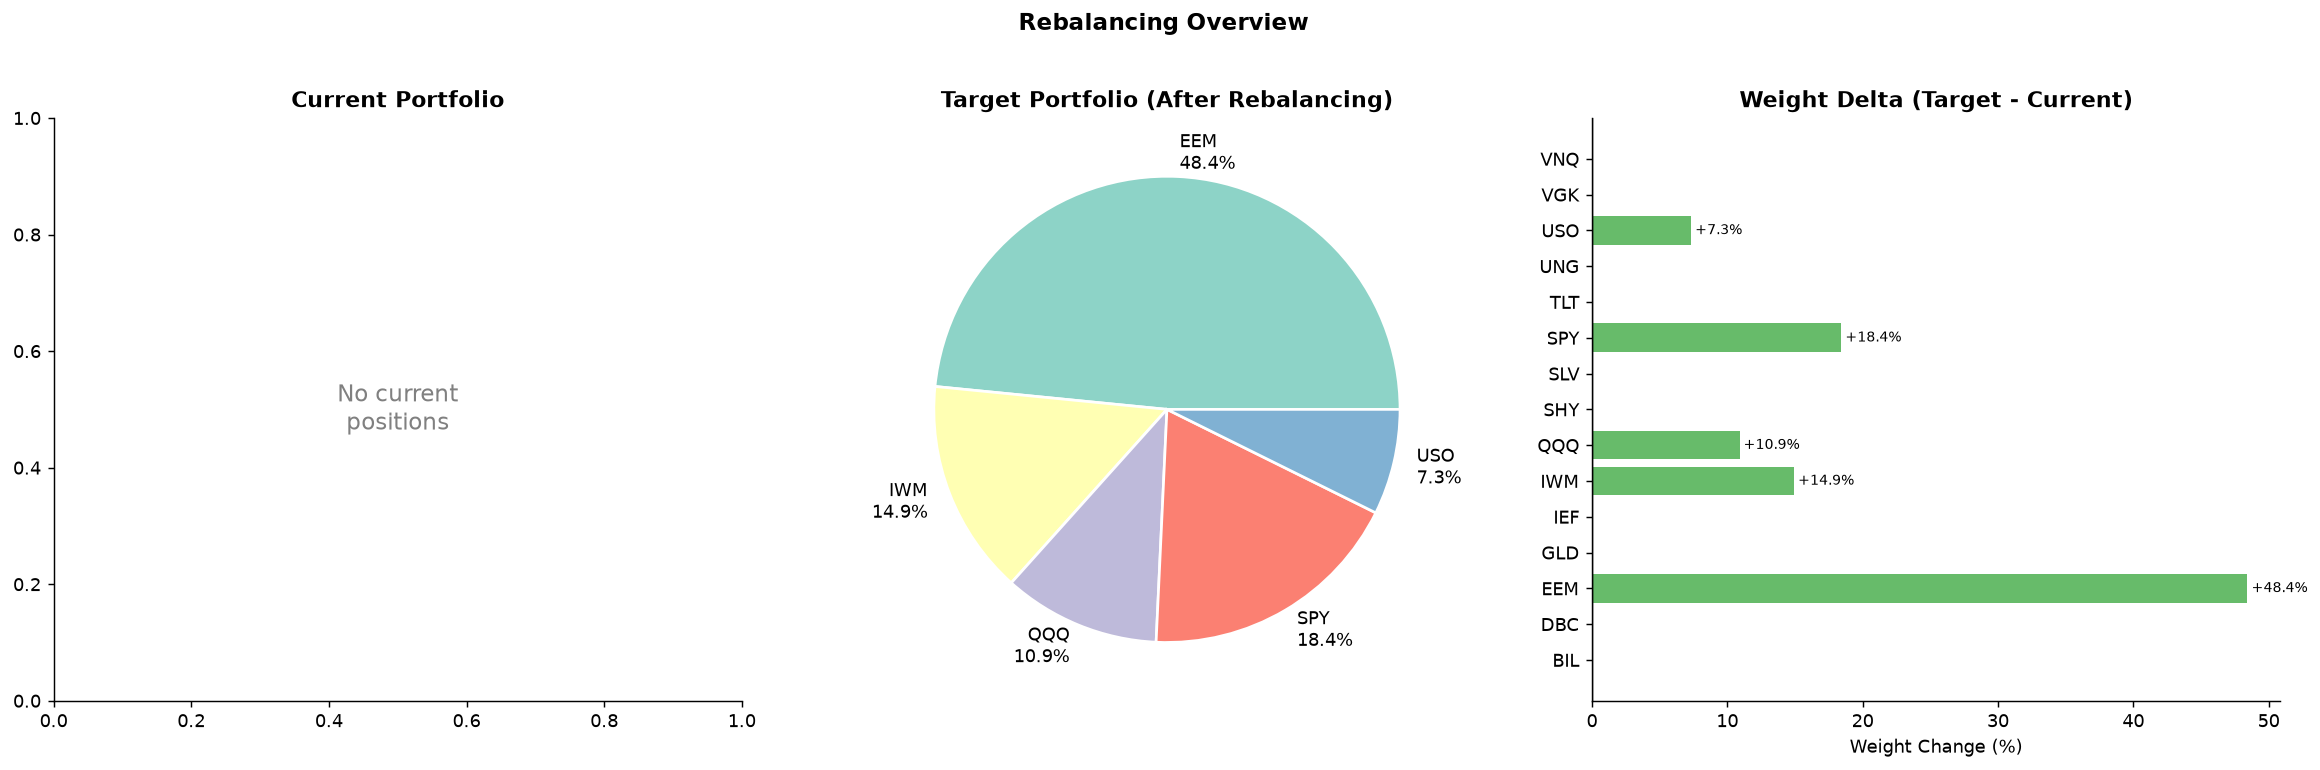

In [59]:
active = trade_df[trade_df['Action'].isin(['BUY','SELL','SELL ALL'])]
curr_wts   = trade_df['Curr Wt %'].values
target_wts = trade_df['Target Wt %'].values
labels     = trade_df['ETF'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Before (current weights)
ax = axes[0]
cw_nonz = [(l, w) for l, w in zip(labels, curr_wts) if w > 0.5]
if cw_nonz:
    lz, wz = zip(*cw_nonz)
    ax.pie(wz, labels=[f'{l}\n{w:.1f}%' for l,w in zip(lz,wz)],
           colors=plt.cm.Set2.colors[:len(lz)],
           wedgeprops={'edgecolor':'white','lw':1.5})
else:
    ax.text(0.5, 0.5, 'No current\npositions', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color='gray')
ax.set_title('Current Portfolio', fontweight='bold')

# After (target weights)
ax = axes[1]
tw_nonz = [(l, w) for l, w in zip(labels, target_wts) if w > 0.5]
if tw_nonz:
    lz, wz = zip(*tw_nonz)
    ax.pie(wz, labels=[f'{l}\n{w:.1f}%' for l,w in zip(lz,wz)],
           colors=plt.cm.Set3.colors[:len(lz)],
           wedgeprops={'edgecolor':'white','lw':1.5})
ax.set_title('Target Portfolio (After Rebalancing)', fontweight='bold')

# Delta bar chart
ax = axes[2]
deltas = target_wts - curr_wts
colors = ['#4CAF50' if d > 0 else '#F44336' if d < -0.5 else '#9E9E9E' for d in deltas]
bars = ax.barh(labels, deltas, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
for bar, d in zip(bars, deltas):
    if abs(d) > 0.5:
        ax.text(d + (0.3 if d > 0 else -0.3), bar.get_y()+bar.get_height()/2,
                f'{d:+.1f}%', va='center', ha='left' if d > 0 else 'right', fontsize=8)
ax.set_xlabel('Weight Change (%)')
ax.set_title('Weight Delta (Target - Current)', fontweight='bold')

plt.suptitle('Rebalancing Overview', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## Cost Breakdown

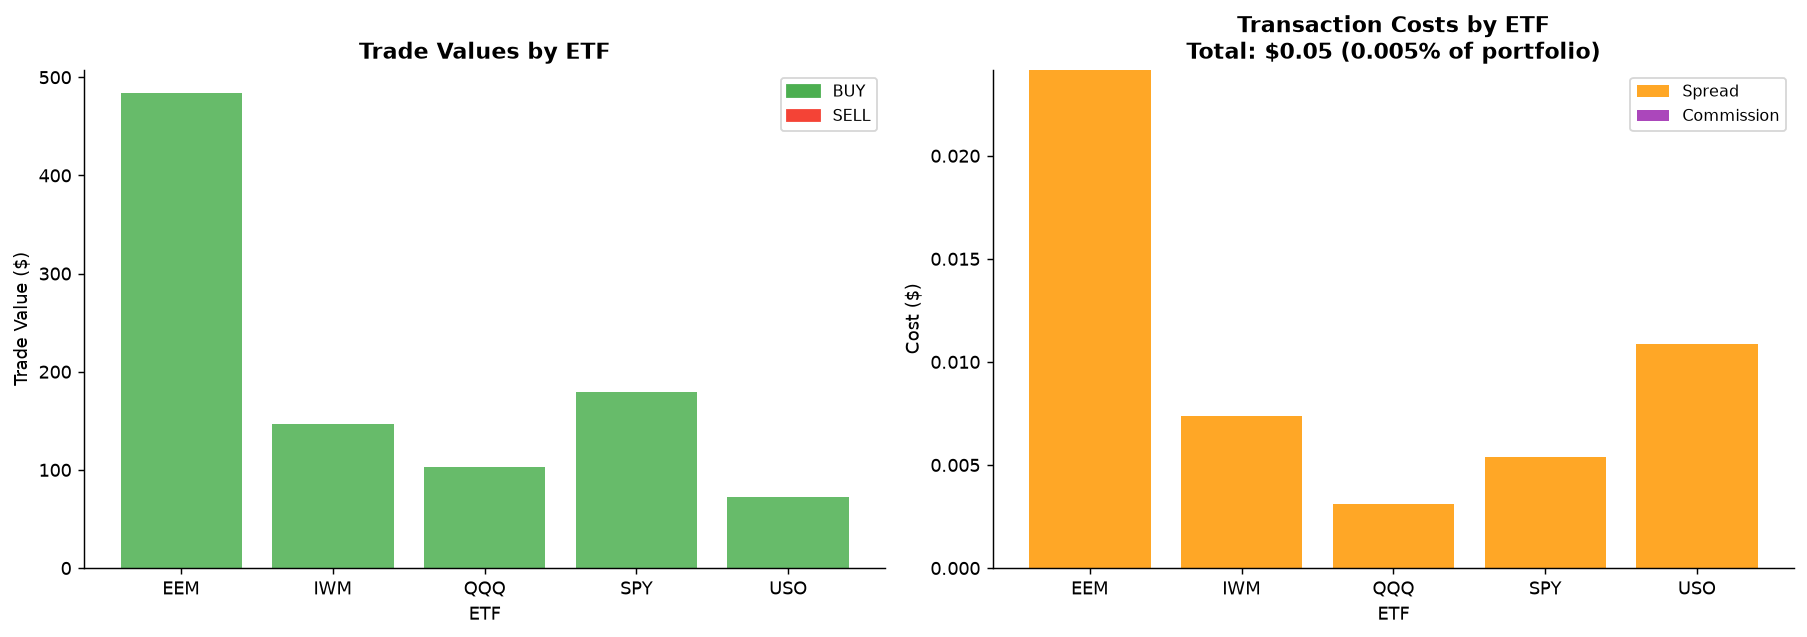

Total spread cost : $0.05
Total commission  : $0.00
Total cost        : $0.05
Cost as % of AUM  : 0.005%


In [60]:
active_trades = trade_df[trade_df['Action'].isin(['BUY','SELL','SELL ALL'])].copy()

if len(active_trades) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.bar(active_trades['ETF'], active_trades['Trade Value'],
           color=['#4CAF50' if a=='BUY' else '#F44336'
                  for a in active_trades['Action']], alpha=0.85)
    ax.set_xlabel('ETF'); ax.set_ylabel(f'Trade Value ({CURRENCY})')
    ax.set_title('Trade Values by ETF', fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#4CAF50', label='BUY'),
                        Patch(color='#F44336', label='SELL')], fontsize=9)

    ax = axes[1]
    cost_types = ['Spread Cost', 'Commission']
    spread_total = active_trades['Spread Cost'].sum()
    comm_total   = active_trades['Commission'].sum()
    bars = ax.bar(active_trades['ETF'],
                  active_trades['Spread Cost'], label='Spread', color='#FF9800', alpha=0.85)
    ax.bar(active_trades['ETF'],
           active_trades['Commission'], bottom=active_trades['Spread Cost'],
           label='Commission', color='#9C27B0', alpha=0.85)
    ax.set_xlabel('ETF'); ax.set_ylabel(f'Cost ({CURRENCY})')
    ax.set_title(f'Transaction Costs by ETF\n'
                 f'Total: {CURRENCY}{active_trades["Total Cost"].sum():.2f} '
                 f'({active_trades["Total Cost"].sum()/current["total"]*100:.3f}% of portfolio)',
                 fontweight='bold')
    ax.legend(fontsize=9)

    plt.tight_layout(); plt.show()
    print(f'Total spread cost : {CURRENCY}{spread_total:.2f}')
    print(f'Total commission  : {CURRENCY}{comm_total:.2f}')
    print(f'Total cost        : {CURRENCY}{active_trades["Total Cost"].sum():.2f}')
    print(f'Cost as % of AUM  : {active_trades["Total Cost"].sum()/current["total"]*100:.3f}%')
else:
    print('No active trades required this month.')

## What If: Broker Cost Comparison

Compute what the same trades would cost at different brokers.

In [61]:
n_active = len(trade_df[trade_df['Action'].isin(['BUY','SELL','SELL ALL'])])
total_trade_val = active_trades['Trade Value'].sum() if len(active_trades) else 0

brokers = [
    {'name': 'IBKR Pro (Tiered)',     'flat': 0.35 * n_active, 'pct': 0.0},
    {'name': 'IBKR Lite (US only)',    'flat': 0.0,             'pct': 0.0},
    {'name': 'Fidelity UK (ETFs)',     'flat': 0.0,             'pct': 0.0},
    {'name': 'Freetrade Plus',          'flat': 0.0,             'pct': 0.0},
    {'name': 'HL (share dealing)',      'flat': 11.95 * n_active,'pct': 0.0},
    {'name': 'HL (monthly saver)',      'flat': 1.50  * n_active,'pct': 0.0},
    {'name': 'Interactive Investor',    'flat': 3.99  * n_active,'pct': 0.0},
]

spread_cost = active_trades['Spread Cost'].sum() if len(active_trades) else 0

print(f'  {"Broker":<30}  {"Spread":>10}  {"Commission":>12}  {"Total":>10}  {"% AUM":>8}')
print(f'  {"-"*30}  {"-"*10}  {"-"*12}  {"-"*10}  {"-"*8}')
for b in brokers:
    tot = spread_cost + b['flat'] + total_trade_val * b['pct'] / 100
    pct = tot / current['total'] * 100 if current['total'] > 0 else 0
    print(f'  {b["name"]:<30}  {CURRENCY}{spread_cost:>9.2f}  {CURRENCY}{b["flat"]:>11.2f}  '
          f'{CURRENCY}{tot:>9.2f}  {pct:>7.3f}%')

  Broker                              Spread    Commission       Total     % AUM
  ------------------------------  ----------  ------------  ----------  --------
  IBKR Pro (Tiered)               $     0.05  $       1.75  $     1.80    0.180%
  IBKR Lite (US only)             $     0.05  $       0.00  $     0.05    0.005%
  Fidelity UK (ETFs)              $     0.05  $       0.00  $     0.05    0.005%
  Freetrade Plus                  $     0.05  $       0.00  $     0.05    0.005%
  HL (share dealing)              $     0.05  $      59.75  $    59.80    5.980%
  HL (monthly saver)              $     0.05  $       7.50  $     7.55    0.755%
  Interactive Investor            $     0.05  $      19.95  $    20.00    2.000%


## Pre-Flight Checklist

Run through this before placing any orders.

In [62]:
from datetime import datetime, timedelta

print('=' * 60)
print('  PRE-FLIGHT CHECKLIST')
print('=' * 60)

checks = []

# 1. Signal date is recent (within 35 days)
days_old = (pd.Timestamp.today() - latest_date).days
c1 = days_old <= 35
checks.append(('Signal is current (<=35 days old)',
                f'{days_old} days old — {latest_date.strftime("%Y-%m-%d")}', c1))

# 2. Prices are live (not stale)
c2 = len(live_prices) >= len(target_weights)
checks.append(('Live prices fetched for all target ETFs',
                f'{len(live_prices)} / {len(all_tickers)} ETFs have prices', c2))

# 3. Cash is sufficient
c3 = cash_check['ok']
checks.append(('Sufficient cash for all buys',
                f'Net cash after: {CURRENCY}{cash_check["net_cash"]:,.2f}', c3))

# 4. At least one active trade (otherwise no rebalance needed)
n_trades = len(trade_df[trade_df['Action'].isin(['BUY','SELL','SELL ALL'])])
c4 = n_trades > 0
checks.append(('Active trades exist',
                f'{n_trades} orders to place', c4 if n_trades > 0 else None))

# 5. Not trading on a holiday or weekend
today = datetime.now()
is_weekday = today.weekday() < 5
checks.append(('Today is a trading day (weekday)',
                today.strftime('%A %Y-%m-%d'), is_weekday))

# 6. Total cost is reasonable
total_cost = trade_df['Total Cost'].sum()
cost_pct   = total_cost / current['total'] * 100 if current['total'] > 0 else 0
c6 = cost_pct < 0.5
checks.append(('Transaction cost < 0.5% of portfolio',
                f'{cost_pct:.3f}% ({CURRENCY}{total_cost:.2f})', c6))

all_ok = True
for label, value, passed in checks:
    if passed is True:
        icon = 'PASS'
    elif passed is False:
        icon = 'FAIL'
        all_ok = False
    else:
        icon = 'INFO'
    print(f'  [{icon}] {label}')
    print(f'         {value}')
    print()

print('=' * 60)
if all_ok:
    print('  READY TO TRADE.')
    print('  Place SELL orders first, then BUY orders.')
    print('  Leave residual cash uninvested until next month.')
else:
    print('  RESOLVE FAILURES BEFORE TRADING.')
print('=' * 60)

  PRE-FLIGHT CHECKLIST
  [PASS] Signal is current (<=35 days old)
         1 days old — 2026-06-30

  [PASS] Live prices fetched for all target ETFs
         15 / 15 ETFs have prices

  [PASS] Sufficient cash for all buys
         Net cash after: $14.37

  [PASS] Active trades exist
         5 orders to place

  [PASS] Today is a trading day (weekday)
         Wednesday 2026-07-01

  [INFO] Transaction cost < 0.5% of portfolio
         0.005% ($0.05)

  READY TO TRADE.
  Place SELL orders first, then BUY orders.
  Leave residual cash uninvested until next month.


## Execution Notes

**Order type**: Use **limit orders** set ~0.05% above ask (buys) / below bid (sells)  
for liquid ETFs like SPY/TLT. Market orders are fine for SPY/QQQ during US market hours  
(09:30–16:00 ET) but avoid the first and last 15 minutes (spreads widen).

**Sequence**: Sell first → receive cash → then buy. This avoids needing margin.

**Settlement**: ETF trades settle T+1. Cash from sells is typically available same-day  
for buying via 'unsettled funds' on most brokers (IBKR, Fidelity UK).

**Currency**: SPY, TLT, GLD etc. are USD-denominated. If your account is GBP,  
IBKR handles conversion automatically (at a small FX spread ~0.5-1bp). 
UK-listed equivalents: CSPX (SPY), IGLT (TLT), SGLN (GLD) if you prefer GBP.

**Do not rebalance if**: The target weights match your current weights within ±2% per ETF  
— the cost of trading doesn't justify the improvement. The threshold above handles this.
